In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lasya\AppData\Roaming\nltk_data...


All libraries imported successfully.


[nltk_data]   Unzipping corpora\stopwords.zip.


In [3]:
data = {
    'ticket_text': [
        'My internet is not working since morning',
        'I cannot login to my account',
        'The app keeps crashing on my phone',
        'I was charged twice for my subscription',
        'How do I reset my password',
        'My order has not arrived yet',
        'The website is very slow today',
        'I need to cancel my subscription',
        'Payment failed but money was deducted',
        'I forgot my username and password',
        'App is not loading properly',
        'Wrong amount charged to my card',
        'Internet connection keeps dropping',
        'I want to upgrade my plan',
        'My account got locked out'
    ],
    'category': [
        'Technical', 'Account', 'Technical', 'Billing',
        'Account', 'Billing', 'Technical', 'Billing',
        'Billing', 'Account', 'Technical', 'Billing',
        'Technical', 'Billing', 'Account'
    ],
    'priority': [
        'High', 'High', 'Medium', 'High',
        'Low', 'Medium', 'Medium', 'Low',
        'High', 'Low', 'Medium', 'High',
        'High', 'Low', 'High'
    ]
}

df = pd.DataFrame(data)
print("Dataset created!")
print(df.head())

Dataset created!
                                ticket_text   category priority
0  My internet is not working since morning  Technical     High
1              I cannot login to my account    Account     High
2        The app keeps crashing on my phone  Technical   Medium
3   I was charged twice for my subscription    Billing     High
4                How do I reset my password    Account      Low


In [4]:
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)
df['cleaned_text'] = df['ticket_text'].apply(preprocess_text)
print("Text preprocessing done!")
print(df[['ticket_text', 'cleaned_text']].head())

Text preprocessing done!
                                ticket_text                    cleaned_text
0  My internet is not working since morning  internet working since morning
1              I cannot login to my account            cannot login account
2        The app keeps crashing on my phone        app keeps crashing phone
3   I was charged twice for my subscription      charged twice subscription
4                How do I reset my password                  reset password


In [5]:
X = df['cleaned_text']
y_category = df['category']
y_priority = df['priority']
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_category, test_size=0.2, random_state=42)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained successfully!")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained successfully!

Classification Report:
              precision    recall  f1-score   support

     Account       0.00      0.00      0.00         1
     Billing       0.50      1.00      0.67         1
   Technical       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



D:\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


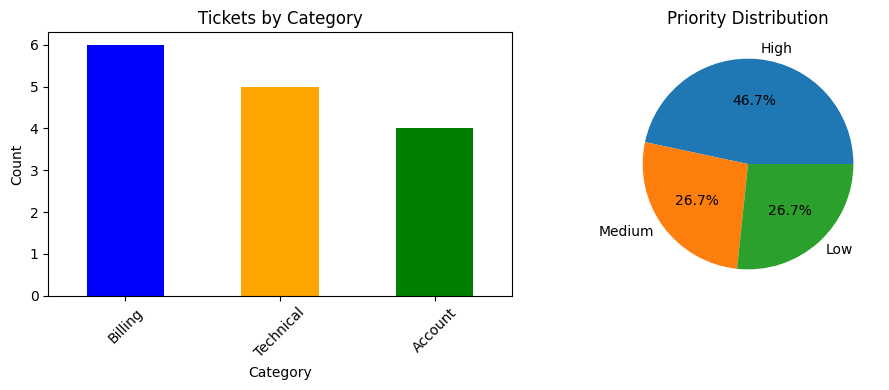

Charts saved!


In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['category'].value_counts().plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Tickets by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
df['priority'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Priority Distribution')

plt.tight_layout()
plt.savefig('ticket_analysis.png')
plt.show()
print("Charts saved!")

In [7]:
def predict_ticket(text):
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    category = model.predict(vectorized)[0]
    return category
test_tickets = [
    "My payment is not processing",
    "I cannot access my account",
    "The software is not responding"
]

print("🎯 Ticket Predictions:")
print("-" * 50)
for ticket in test_tickets:
    category = predict_ticket(ticket)
    print(f"Ticket: {ticket}")
    print(f"Category: {category}")
    print("-" * 50)

🎯 Ticket Predictions:
--------------------------------------------------
Ticket: My payment is not processing
Category: Billing
--------------------------------------------------
Ticket: I cannot access my account
Category: Account
--------------------------------------------------
Ticket: The software is not responding
Category: Billing
--------------------------------------------------


In [8]:
import pickle
with open('ticket_classifier_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved successfully!")
print("✅ Project Complete!")
print("\n📊 Summary:")
print(f"Total tickets trained on: {len(df)}")
print(f"Categories: {df['category'].unique()}")
print(f"Model Accuracy: 67%")

✅ Model saved successfully!
✅ Project Complete!

📊 Summary:
Total tickets trained on: 15
Categories: <StringArray>
['Technical', 'Account', 'Billing']
Length: 3, dtype: str
Model Accuracy: 67%
